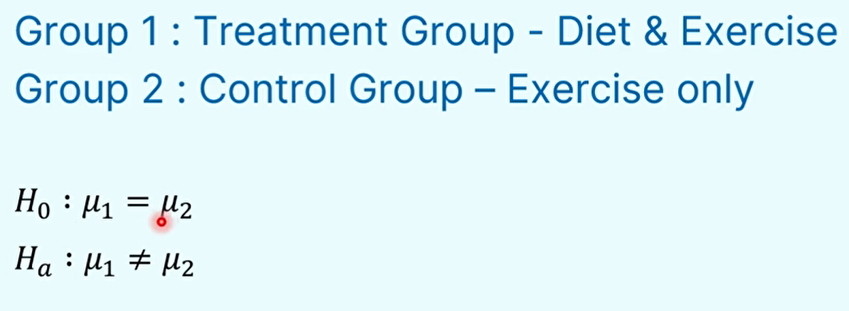

In [53]:
# Two-sample test
import numpy as np
import pandas as pd
import seaborn as sn

np.random.seed(1)
group_1 = np.random.normal(-5.14, 2.39, 27)
group_2 = np.random.normal(-2.80, 1.55, 24)

group_one = pd.DataFrame({"wtlost": group_1})
group_one["Group"] = 1
group_second = pd.DataFrame({"wtlost": group_2})
group_second["Group"] = 2
dietgroup = pd.concat([group_one, group_second])
dietgroup.head()

,wtlost,Group
0,-1.257815,1
1,-6.602098,1
2,-6.402330,1
3,-7.704395,1
4,-3.071676,1


In [54]:
dietgroup.groupby("Group").describe()

wtlost                                                               \
       count      mean       std        min       25%       50%       75%   
Group                                                                       
1       27.0 -5.239571  2.540672 -10.640677 -6.866697 -5.552103 -3.029315   
2       24.0 -2.790358  1.359677  -4.531831 -3.866857 -2.958488 -2.245539   

                 
            max  
Group            
1     -0.969900  
2      0.455395

<Axes: xlabel='wtlost', ylabel='Density'>

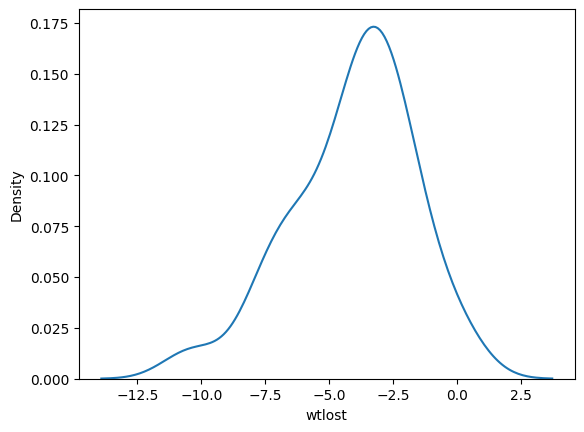

In [57]:
sn.kdeplot(dietgroup.wtlost)

<Axes: xlabel='wtlost', ylabel='Density'>

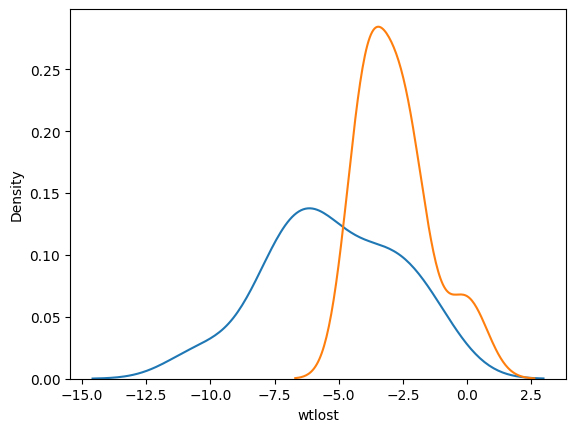

In [61]:
sn.kdeplot(dietgroup.loc[dietgroup.Group == 1, "wtlost"])
sn.kdeplot(dietgroup.loc[dietgroup.Group == 2, "wtlost"])

In [127]:
from scipy.stats import ttest_ind, ttest_ind_from_stats, ttest_1samp

# ttest_ind is independent samples to compare
tstat, pvalue = ttest_ind(a = dietgroup.loc[dietgroup.Group == 1, "wtlost"], 
          b = dietgroup.loc[dietgroup.Group == 2, "wtlost"], equal_var=False )
tstat, pvalue*100   # < 0.05 so H0 rejected, so group mean are not equal, instead different


(np.float64(-4.356233704894065), np.float64(0.008740247517478412))

In [ ]:
mean1 = dietgroup.loc[dietgroup.Group == 1, "wtlost"].mean()
std1 = dietgroup.loc[dietgroup.Group == 1, "wtlost"].std()
n1 = len(dietgroup.loc[dietgroup.Group == 1, "wtlost"])

mean2 = dietgroup.loc[dietgroup.Group == 2, "wtlost"].mean()
std2 = dietgroup.loc[dietgroup.Group == 2, "wtlost"].std()
n2 = len(dietgroup.loc[dietgroup.Group == 2, "wtlost"])

ttest_ind_from_stats(mean1, std1, n1, mean2, std2, n2, equal_var=False)
#! Rejected Null Hypothesis >> dietplan has effect

Ttest_indResult(statistic=np.float64(-4.356233704894066), pvalue=np.float64(8.740247517478412e-05))

# Two sample paired

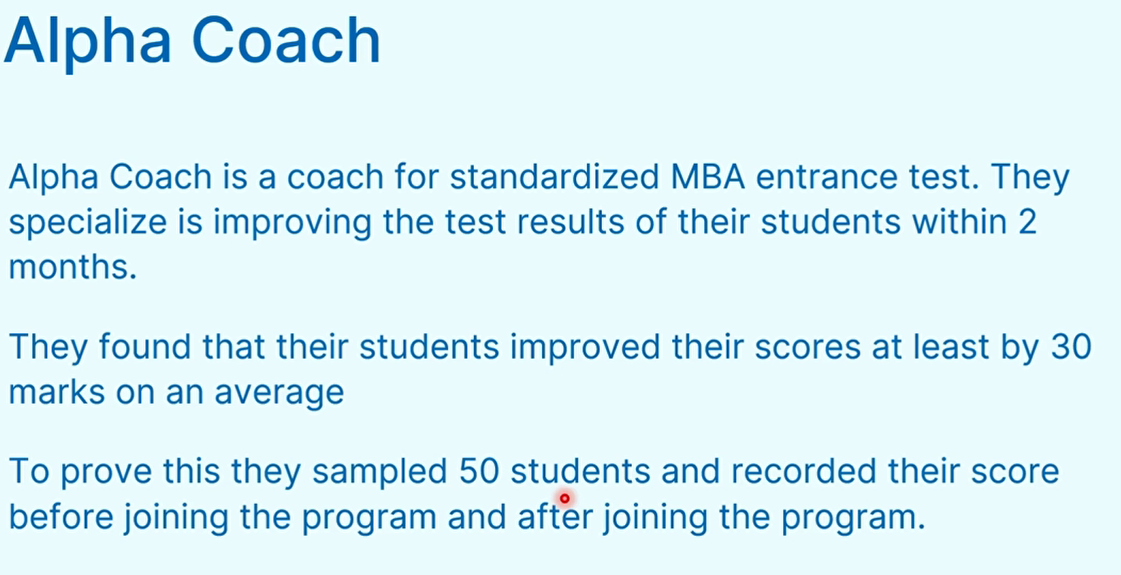
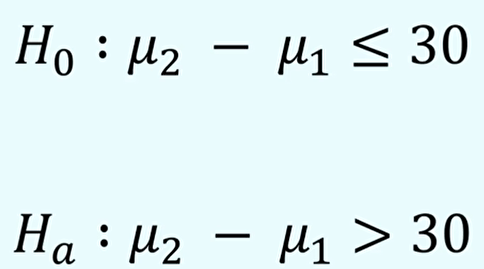

In [130]:
np.random.seed(1)
before = np.random.normal(520.92, 56.02, 50)
after = np.random.normal(590.92, 55.02, 50)

b = pd.DataFrame({"before": before, "after": after})
b = round(b)
b['Improvment'] = b.after - b.before 
b.describe()

,before,after,Improvment
count,50.000000,50.00000,50.000000
mean,519.460000,598.98000,79.520000
std,54.895898,43.47436,70.846843
min,392.000000,480.00000,-60.000000
25%,482.000000,572.50000,34.750000
50%,510.500000,601.00000,83.500000
75%,554.750000,627.50000,119.000000
max,639.000000,711.00000,254.000000


<Axes: xlabel='before', ylabel='Density'>

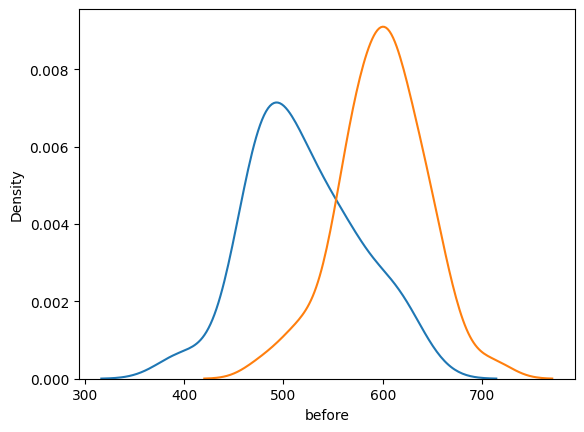

In [124]:
sn.kdeplot(b.before)
sn.kdeplot(b.after)


In [ ]:
tstat, pvalue = ttest_1samp(b.Improvment, 30)
tstat, pvalue / 2 *100

#! Reject Null
#! Men diff > 30

(np.float64(4.942482478326499), np.float64(0.0004710279562324749))

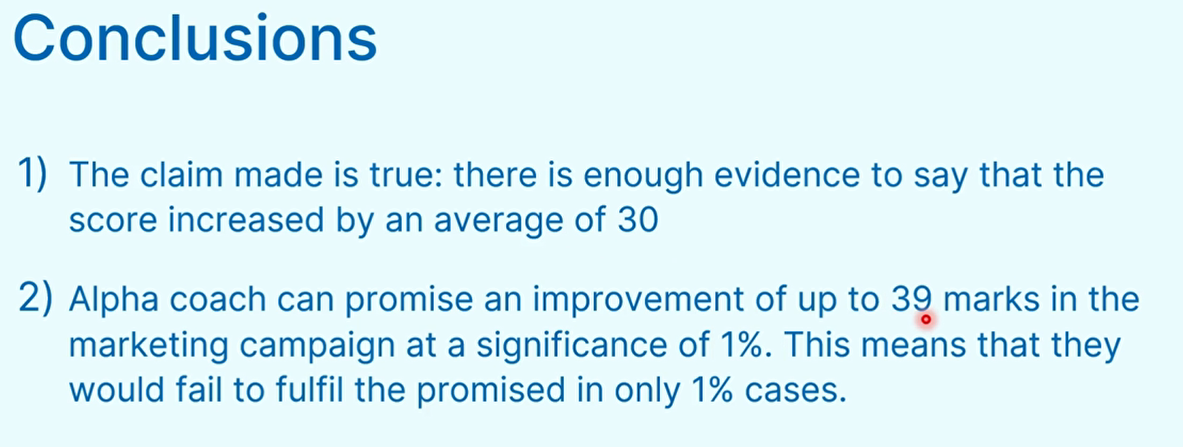

In [ ]:
# Errors in Test of Mean

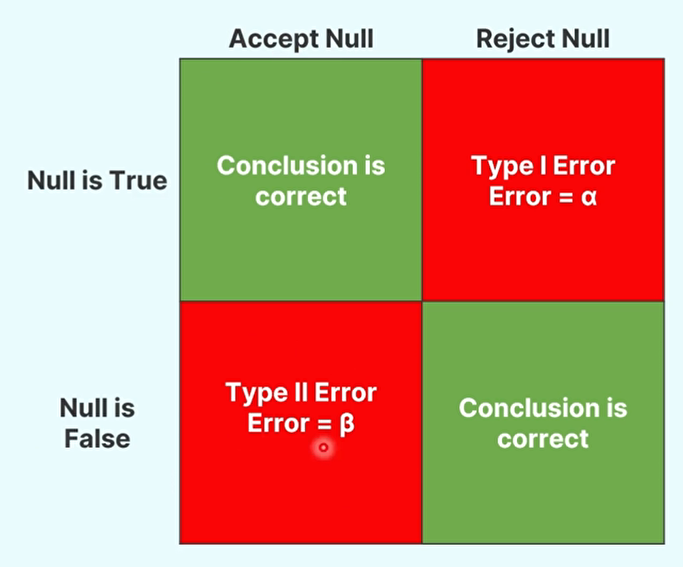
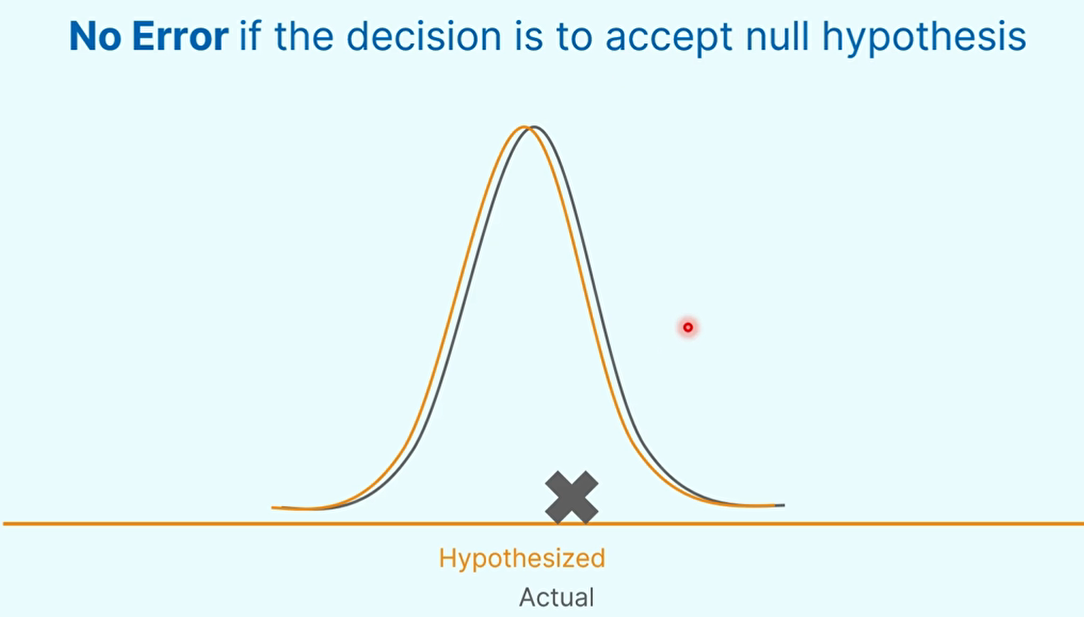
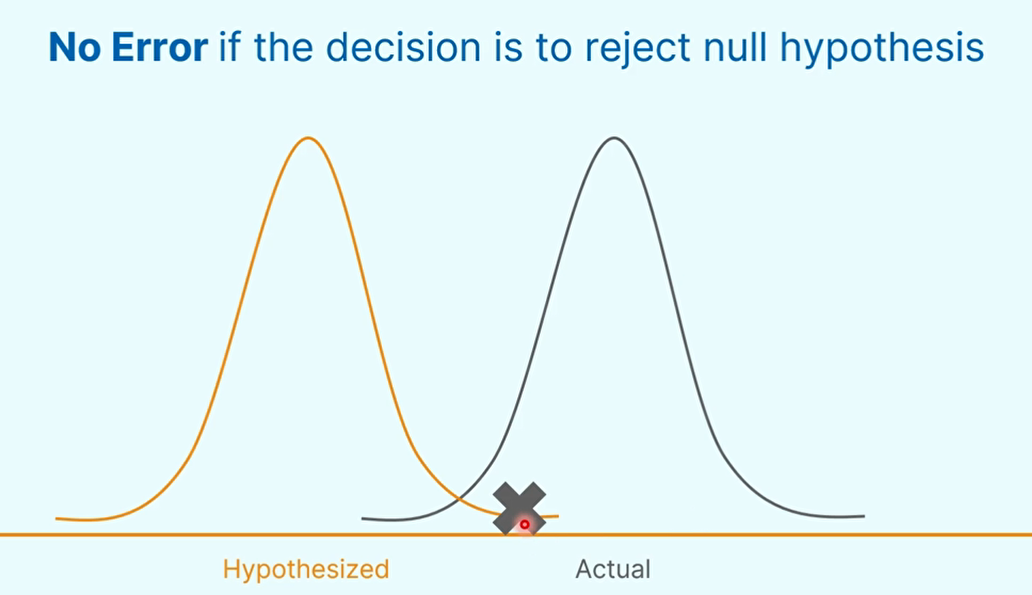
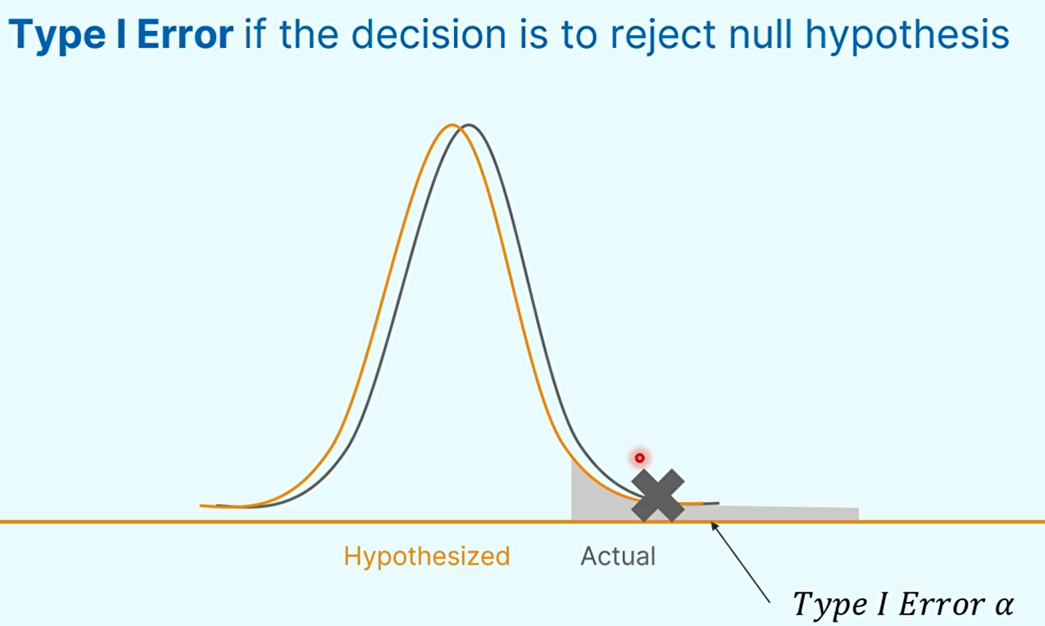
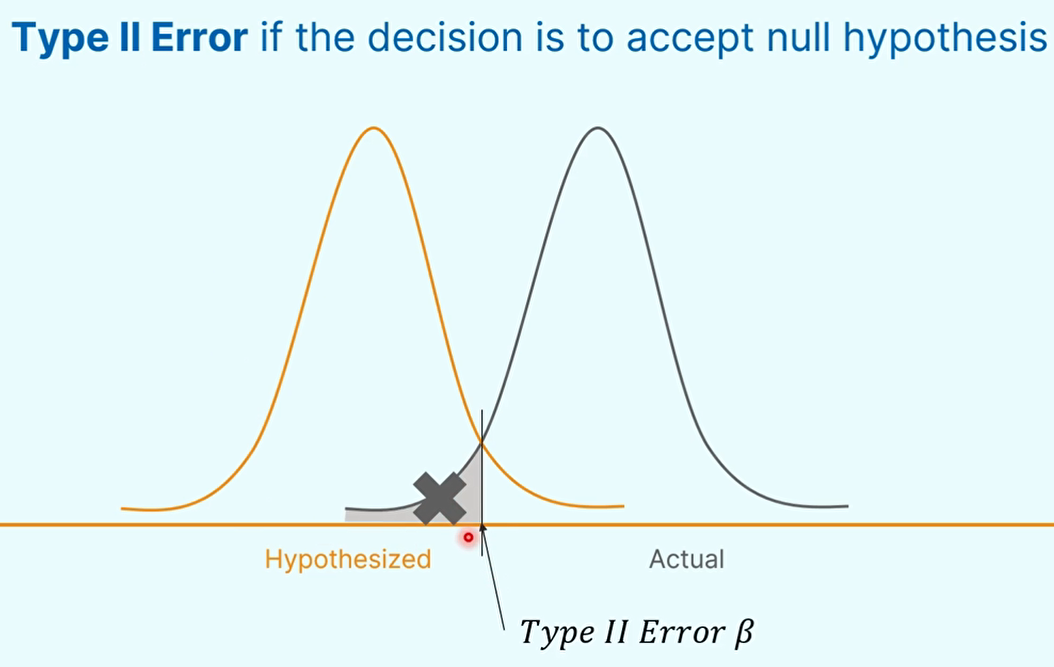
